In [5]:
from test.helpers import sde_solver_order
from test.test_langevin import langevin_diffusion, langevin_drift

import diffrax
import equinox as eqx
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt
from diffrax import ALIGN, SEA, ShARK, SRA1
from jax import config


config.update("jax_enable_x64", True)


def draw_order(hs, errs):
    plt.plot(1 / hs, errs)
    plt.yscale("log")
    plt.xscale("log")
    pretty_hs = ["{0:0.4f}".format(h) for h in hs]
    plt.xticks(ticks=1 / hs, labels=pretty_hs)
    plt.ylabel("RMS error")
    plt.xlabel("step size")
    plt.show()
    slope, _ = jnp.polyfit(jnp.log(hs), jnp.log(errs), 1)
    print(f"Order of convergence: {slope:.4f}")


def _squareplus(x):
    return 0.5 * (x + jnp.sqrt(x**2 + 4))


def sde_strong_order(solver_ctr, commutative, theoretical_order):
    key = jrandom.PRNGKey(5678)
    driftkey, diffusionkey, ykey, bmkey = jrandom.split(key, 4)
    num_samples = 20
    bmkeys = jrandom.split(bmkey, num=num_samples)

    if commutative:
        noise_dim = 1
    else:
        noise_dim = 5

    def drift(t, y, args):
        mlp = eqx.nn.MLP(
            in_size=3,
            out_size=3,
            width_size=8,
            depth=1,
            activation=_squareplus,
            key=driftkey,
        )
        return 0.5 * mlp(y)

    def diffusion(t, y, args):
        mlp = eqx.nn.MLP(
            in_size=3,
            out_size=3 * noise_dim,
            width_size=8,
            depth=1,
            activation=_squareplus,
            final_activation=jnp.tanh,
            key=diffusionkey,
        )
        return 0.25 * mlp(y).reshape(3, noise_dim)

    t0 = 0
    t1 = 2
    y0 = jrandom.normal(ykey, (3,), dtype=jnp.float64)

    sde = (drift, diffusion, None, y0, t0, t1, noise_dim)

    # Reference solver is always an ODE-viable solver, so its implementation has been
    # verified by the ODE tests like test_ode_order.
    if issubclass(solver_ctr, diffrax.AbstractItoSolver):
        ref_solver = diffrax.Euler()
    elif issubclass(solver_ctr, diffrax.AbstractStratonovichSolver):
        ref_solver = diffrax.Heun()
    else:
        assert False

    hs, errors, order = sde_solver_order(
        bmkeys, sde, solver_ctr(), ref_solver, 2**-14, hs_num=7
    )
    log_errs = jnp.log2(errors)
    slopes = log_errs[:-1] - log_errs[1:]
    assert -0.2 < order - theoretical_order < 0.2
    return order, slopes

In [2]:
def _solvers():
    # solver, commutative, order
    yield diffrax.Euler, False, 0.5, "Euler"  # PASSES
    yield diffrax.EulerHeun, False, 0.5, "EulerHeun"  # 0.9326
    yield diffrax.Heun, False, 0.5, "Heun"  # 0.86656
    yield diffrax.ItoMilstein, False, 0.5, "ItoMilstein"  # 1.0025
    yield diffrax.Midpoint, False, 0.5, "Midpoint"  # 0.8659
    yield diffrax.ReversibleHeun, False, 0.5, "ReversibleHeun"  # 0.8666
    yield diffrax.StratonovichMilstein, False, 0.5, "StratonovichMilstein"  # 0.9331
    yield diffrax.ReversibleHeun, True, 1.0, "ReversibleHeun"  # 1.3648
    yield diffrax.StratonovichMilstein, True, 1.0, "StratonovichMilstein"  # PASSES

In [7]:
slopes_dict = {}
for solver, comm, theoretical_order, name in _solvers():
    order, slopes = sde_strong_order(solver, comm, theoretical_order)
    pretty_slopes = ["{0:0.5f}".format(slope) for slope in slopes]
    slopes_dict.update({name: pretty_slopes})
    print(f"{name} has slopes {pretty_slopes} and order {order:.5f}")

Heun has slopes ['0.57572', '0.85757', '0.13873', '0.54256', '0.47378', '0.66119'] and order 0.51626
ItoMilstein has slopes ['0.71535', '0.87469', '0.30138', '0.55191', '0.47130', '0.66119'] and order 0.57069
Midpoint has slopes ['0.57397', '0.86080', '0.13611', '0.54239', '0.47405', '0.66096'] and order 0.51607
ReversibleHeun has slopes ['0.57591', '0.85719', '0.13902', '0.54254', '0.47369', '0.66119'] and order 0.51625
StratonovichMilstein has slopes ['0.71600', '0.87569', '0.29244', '0.56685', '0.49206', '0.68670'] and order 0.57866
ReversibleHeun has slopes ['0.75643', '0.96169', '0.91476', '1.13479', '0.78509', '0.92417'] and order 0.93118
StratonovichMilstein has slopes ['1.01076', '0.99114', '1.00239', '0.99731', '1.01628', '0.97563'] and order 0.99980


In [2]:
num_samples = 100
keys = jrandom.split(jrandom.PRNGKey(5678), num=num_samples)

t0, t1 = 0.3, 15

gamma_hosc = jnp.array([2, 0.5], dtype=jnp.float64)
u_hosc = jnp.array([0.5, 2], dtype=jnp.float64)
args_hosc = (gamma_hosc, u_hosc, lambda x: 2 * x)
y0_hosc = jnp.zeros((4,), dtype=jnp.float64)
w_dim_hosc = 2
harmonic_osc = (
    langevin_drift,
    langevin_diffusion,
    args_hosc,
    y0_hosc,
    t0,
    t1,
    w_dim_hosc,
)

grad_f_bqp = lambda x: 4 * x * (jnp.square(x) - 1)
args_bqp = (jnp.float64(0.8), jnp.float64(0.2), grad_f_bqp)
y0_bqp = jnp.zeros((2,), dtype=jnp.float64)
w_dim_bqp = 1
bqp = (langevin_drift, langevin_diffusion, args_bqp, y0_bqp, t0, t1, w_dim_bqp)

hs1 = jnp.power(2.0, jnp.arange(0, -8, -1, dtype=jnp.float64))
hs2 = jnp.power(2.0, jnp.arange(-3, -9, -1, dtype=jnp.float64))
hs3 = jnp.power(2.0, jnp.arange(-2, -10, -1, dtype=jnp.float64))

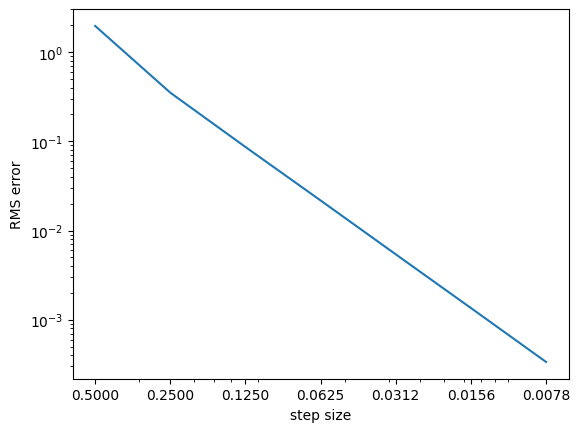

Order of convergence: 2.0557


In [3]:
_, errs_shark_hosc, order_shark_hosc = sde_solver_order(
    keys, harmonic_osc, ShARK(), ALIGN(0.1), 2**-10, hs=hs1
)
draw_order(hs1[1:], errs_shark_hosc[1:])

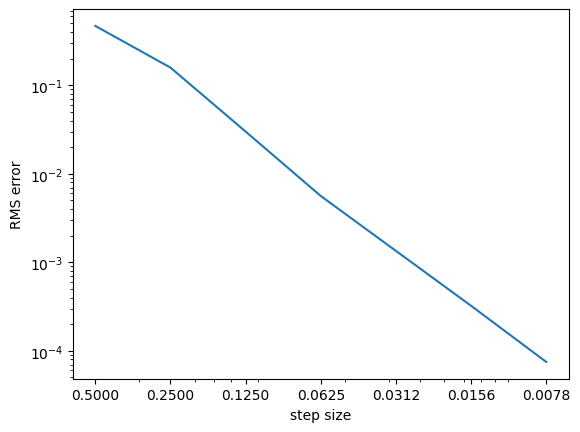

Order of convergence: 2.1497


In [4]:
_, errs_shark_bqp, order_shark_bqp = sde_solver_order(
    keys, bqp, ShARK(), ALIGN(0.1), 2**-10, hs=hs1
)
draw_order(hs1[1:], errs_shark_bqp[1:])

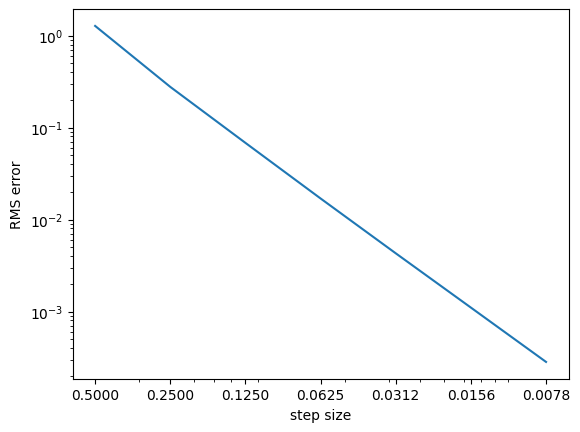

Order of convergence: 2.0119


In [9]:
_, errs_sra_hosc, order_sra_hosc = sde_solver_order(
    keys, harmonic_osc, SRA1(), ALIGN(0.1), 2**-11, hs=hs1
)
draw_order(hs1[1:], errs_sra_hosc[1:])

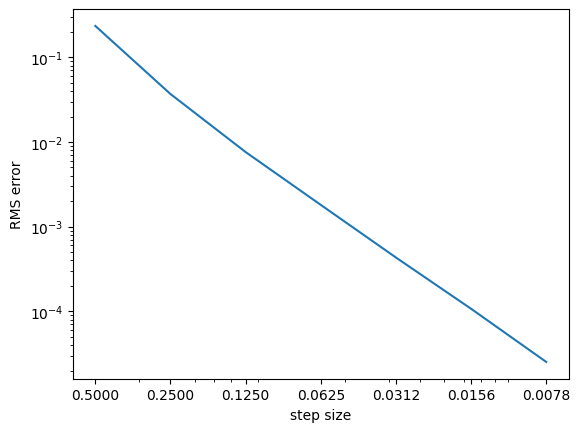

Order of convergence: 2.1623


In [10]:
_, errs_sra_bqp, order_sra_bqp = sde_solver_order(
    keys, bqp, SRA1(), ALIGN(0.1), 2**-11, hs=hs1
)
draw_order(hs1[1:], errs_sra_bqp[1:])

In [11]:
print(f"shark_hosc {errs_shark_hosc[-1]:.5f}")
print(f"sra_hosc   {errs_sra_hosc[-1]:.5f}")
print(f"shark_bqp  {errs_shark_bqp[-1]:.5f}")
print(f"sra_bqp    {errs_sra_bqp[-1]:.5f}")

shark_hosc 0.00512
sra_hosc   0.00028
shark_bqp  0.00138
sra_bqp    0.00003


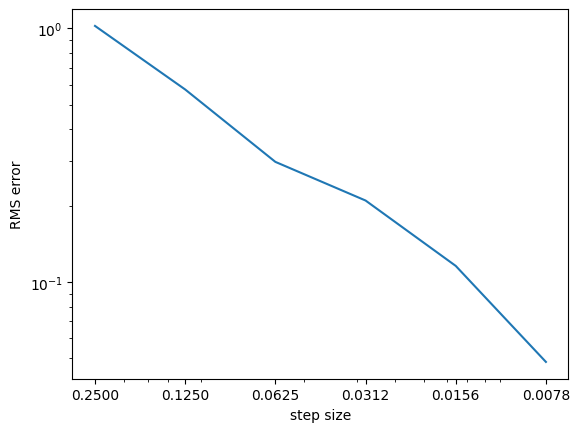

Order of convergence: 0.8414


In [10]:
_, errs_sea_bqp, order_sea_bqp = sde_solver_order(
    keys, bqp, SEA(), ALIGN(0.1), 2**-10, hs=hs1
)
draw_order(hs1[2:], errs_sea_bqp[2:])

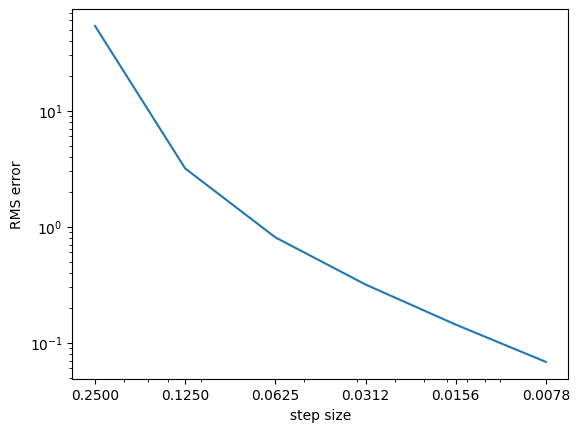

Order of convergence: 1.7961


In [14]:
_, errs_sea_hosc, order_sea_hosc = sde_solver_order(
    keys, harmonic_osc, SEA(), ALIGN(0.1), 2**-10, hs=hs1
)
draw_order(hs1[2:], errs_sea_hosc[2:])

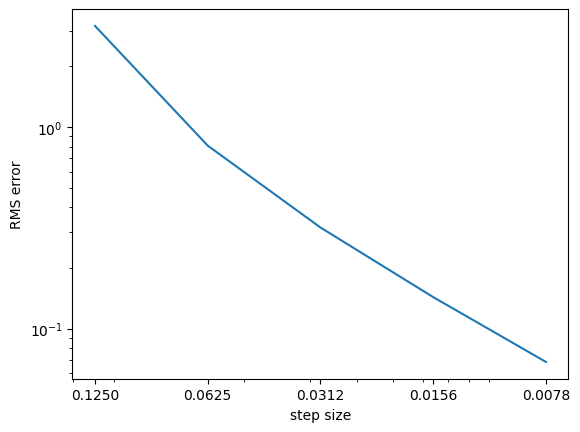

Order of convergence: 1.3576


In [16]:
draw_order(hs1[3:], errs_sea_hosc[3:])